In [1]:
#Loading libraries
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggh4x)
library(cluster)
library(ape)
library(vegan)
library(grid)
library(paletteer)
library(patchwork)
library(purrr)

Warning message:
“package ‘dplyr’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Warning message:
“package ‘cluster’ was built under R version 4.5.2”

Attaching package: ‘ape’


The following object is masked from ‘package:dplyr’:

    where


Warning message:
“package ‘vegan’ was built under R version 4.5.2”
Loading required package: permute

Warning message:
“package ‘permute’ was built under R version 4.5.2”
Warning message:
“package ‘paletteer’ was built under R version 4.5.2”
Warning message:
“package ‘purrr’ was built under R version 4.5.2”


In [2]:
#Loading and formatting tables
#Reading table files
metadata <- read.delim("replicon_all_metadata_tax.tsv",stringsAsFactors = FALSE)
markers <- read.delim("replicon_features_markers.tsv",stringsAsFactors = FALSE)

# Keep only the marker-specific columns
markers <- markers %>%
  select(genome, contig,
    starts_with("CHR_"),
    starts_with("PART_"),
    starts_with("PLAS_"),
    codon_corr_chr1)

# Merging
replicon_all <- metadata %>%
  left_join(markers, by = c("genome", "contig"))

# Filtering too small plasmids and non-Halboacteriota
tables1 <- replicon_all %>% filter(phylum == "Halobacteriota")
#write.table(tables1, "TS1.tsv",sep="\t",quote=FALSE,row.names=FALSE)

feat <- replicon_all %>%
    filter(phylum == "Halobacteriota",
        !is.na(codon_corr_chr1)) %>%
    mutate(logLength = log10(length))

plas <- feat %>%
    filter(replicon == "plasmid")

head(plas)
dim(plas)
colnames(plas)

,genome,contig,replicon,length,gc_content,gtdb_markers,tnf_corr_best_gtdb,chr1_presence,chr1_hits,partition_presence,⋯,PLAS_RepC,PLAS_Replitron_HUH,PLAS_RepA_N_hits,PLAS_RepA_C_hits,PLAS_RepB_hits,PLAS_RepB_C_hits,PLAS_RepC_hits,PLAS_Replitron_HUH_hits,codon_corr_chr1,logLength
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,GCF_000006805.1,NC_001869.1,plasmid,191346,57.91,0,0.8583350,2,3,2,⋯,0,0,0,0,0,0,0,0,0.9230006,5.281819
2,GCF_000006805.1,NC_002608.1,plasmid,365425,59.22,1,0.9040631,2,4,2,⋯,0,0,0,0,0,0,0,0,0.9497000,5.562798
3,GCF_000009185.1,NC_008213.1,plasmid,46867,47.67,0,0.8922150,0,0,1,⋯,0,0,0,0,0,0,0,0,0.6894085,4.670867
4,GCF_000011085.1,NC_006389.1,plasmid,33303,54.25,0,0.8247487,2,1,0,⋯,0,0,0,0,0,0,0,0,0.9205699,4.522483
5,GCF_000011085.1,NC_006390.1,plasmid,33452,55.63,0,0.8665407,0,0,2,⋯,0,0,0,0,0,0,0,0,0.8971279,4.524422
6,GCF_000011085.1,NC_006391.1,plasmid,39521,60.02,0,0.9648247,2,2,1,⋯,0,0,0,0,0,0,0,0,0.9608552,4.596828


[1] 512  62

[1] "genome"                  "contig"                 
 [3] "replicon"                "length"                 
 [5] "gc_content"              "gtdb_markers"           
 [7] "tnf_corr_best_gtdb"      "chr1_presence"          
 [9] "chr1_hits"               "partition_presence"     
[11] "partition_hits"          "plasmid_presence"       
[13] "plasmid_hits"            "phylum"                 
[15] "class"                   "order"                  
[17] "family"                  "genus"                  
[19] "species"                 "chr1_gc"                
[21] "delta_gc"                "abs_delta_gc"           
[23] "CHR_Cdc6_lid"            "CHR_WHD_Cdc6"           
[25] "CHR_MCM"                 "CHR_GINS23_N"           
[27] "CHR_RNA_pol_Rpb2_1"      "CHR_RFC1"               
[29] "CHR_Gins15_N"            "CHR_Cdc6_lid_hits"      
[31] "CHR_WHD_Cdc6_hits"       "CHR_GINS23_N_hits"      
[33] "CHR_MCM_hits"            "CHR_RNA_pol_Rpb2_1_hits"
[35] "CHR_Gins15_N_hits"       "CHR_RFC1_hits"          
[37] "PART_ParA"               "PART_ParB_N"            
[39] "PART_ParB"               "PART_HTH_ParB"          
[41] "PART_ParB_C"             "PART_CB_ParB_C"         
[43] "PART_HTH_ParB_hits"      "PART_ParA_hits"         
[45] "PART_ParB_hits"          "PART_ParB_N_hits"       
[47] "PART_ParB_C_hits"        "PART_CB_ParB_C_hits"    
[49] "PLAS_RepA_N"             "PLAS_RepA_C"            
[51] "PLAS_RepB"               "PLAS_RepB_C"            
[53] "PLAS_RepC"               "PLAS_Replitron_HUH"     
[55] "PLAS_RepA_N_hits"        "PLAS_RepA_C_hits"       
[57] "PLAS_RepB_hits"          "PLAS_RepB_C_hits"       
[59] "PLAS_RepC_hits"          "PLAS_Replitron_HUH_hits"
[61] "codon_corr_chr1"         "logLength"

n_genomes,n_chr2,percentage_chr2
<int>,<int>,<dbl>
211,9,4.265403


Saving 6.67 x 6.67 in image


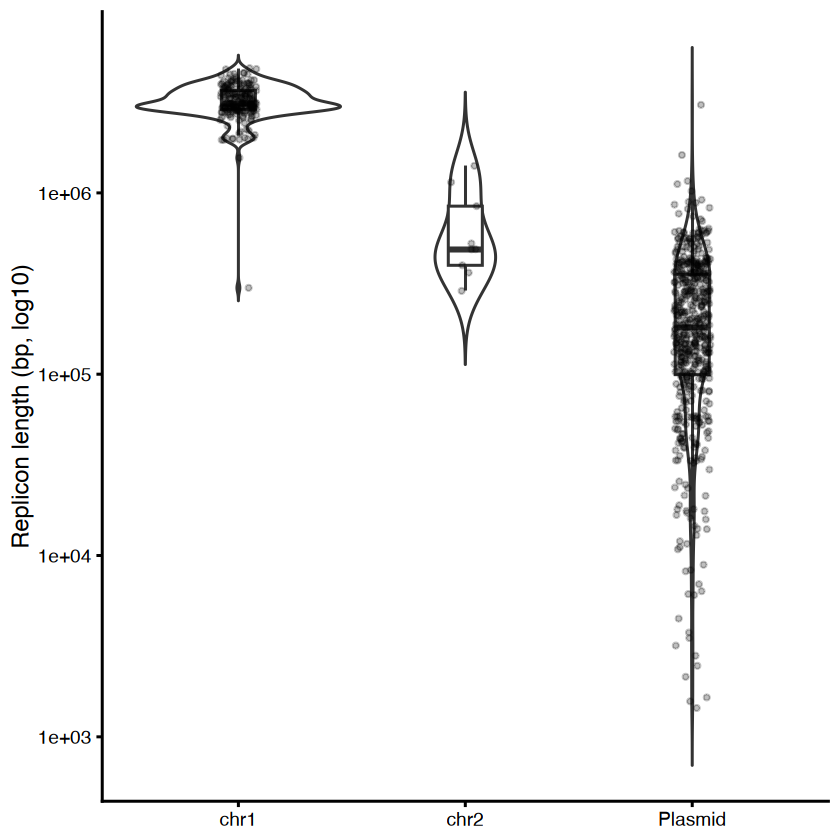

In [3]:
#Number of Halobacteriota with chr2
replicon_all %>%
  filter(phylum == "Halobacteriota") %>%
  summarise(n_genomes = n_distinct(genome),
    n_chr2 = n_distinct(genome[replicon == "chr2plus"]),
    percentage_chr2 = 100 * n_chr2 / n_genomes)

#Distribution of replicon sizes
size_dat <- replicon_all %>%
  filter(phylum == "Halobacteriota",
    replicon %in% c("chr1", "chr2plus", "plasmid"),
    !is.na(length),
    length > 0) %>%
  mutate(
    replicon = factor(replicon,
      levels = c("chr1", "chr2plus", "plasmid"),
      labels = c("chr1", "chr2", "Plasmid")))

#Plotting
ggplot(size_dat, aes(x = replicon, y = length)) +
  geom_violin(trim = FALSE,
    alpha = 0.5) +
  geom_boxplot(width = 0.15,
    outlier.shape = NA) +
  geom_jitter(width = 0.08,
    alpha = 0.25,
    size = 1) +
  scale_y_log10() +
  theme_classic(base_size = 14) +
  labs(x = NULL,
    y = "Replicon length (bp, log10)")
ggsave("./paper/rep_size.svg")

In [4]:
#Creating features summaries by replicon type and by taxonomic family
#Genome sizes (sum of all replicons)
genome_stats <- replicon_all %>%
  filter(phylum == "Halobacteriota") %>%
  group_by(genome, family) %>%
  summarise(Genome_length = sum(length),
    Genome_GC = weighted.mean(gc_content, length),
    n_replicons = n(),
    n_plasmids = sum(replicon == "plasmid"),
    has_chr2 = any(replicon == "chr2plus"),
    .groups = "drop")

#Summary by family
family_summary <- genome_stats %>%
  group_by(family) %>%
  summarise(Genomes = n(),
    Plasmids = sum(n_plasmids),
    Secondary_chromosomes = sum(has_chr2),
    Min_genome_length = min(Genome_length),
    Mean_genome_length = round(mean(Genome_length)),
    Max_genome_length = max(Genome_length),
    Min_genome_GC = round(min(Genome_GC),2),
    Mean_genome_GC = round(mean(Genome_GC),2),
    Max_genome_GC = round(max(Genome_GC),2),
    .groups = "drop") %>%
  arrange(desc(Genomes))

family_summary
write.table(family_summary, "./paper/family_stats.tsv", sep="\t", quote=FALSE, row.names=FALSE)

#Summary by replicon type
replicon_summary <- replicon_all %>%
  filter(phylum=="Halobacteriota") %>%
  group_by(replicon) %>%
  summarise(
    Replicons = n(),
    Min_length = min(length),
    Mean_length = round(mean(length)),
    Max_length = max(length),
    Min_GC = round(min(gc_content),2),
    Mean_GC = round(mean(gc_content),2),
    Max_GC = round(max(gc_content),2),
    .groups="drop")

replicon_summary
write.table(replicon_summary, "./paper/replicon_stats.tsv", sep="\t", quote=FALSE, row.names=FALSE)

#Overall dataset summary
overall_summary <- tibble(
  Families = n_distinct(genome_stats$family),
  Genomes = nrow(genome_stats),
  Replicons = nrow(replicon_all %>%
                     filter(phylum=="Halobacteriota")),
  Primary_chromosomes = sum(replicon_all$phylum=="Halobacteriota" & replicon_all$replicon=="chr1"),
  Secondary_chromosomes = sum(replicon_all$phylum=="Halobacteriota" & replicon_all$replicon=="chr2plus"),
  Plasmids = sum(replicon_all$phylum=="Halobacteriota" & replicon_all$replicon=="plasmid"),
  Smallest_genome = min(genome_stats$Genome_length),
  Largest_genome = max(genome_stats$Genome_length),
  Lowest_genome_GC = round(min(genome_stats$Genome_GC),2),
  Highest_genome_GC = round(max(genome_stats$Genome_GC),2))

overall_summary

family,Genomes,Plasmids,Secondary_chromosomes,Min_genome_length,Mean_genome_length,Max_genome_length,Min_genome_GC,Mean_genome_GC,Max_genome_GC
<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Haloferacaceae,58,133,2,2853958,3642839,4973118,47.67,65.27,71.29
Haloarculaceae,54,141,5,2749696,3973730,5327573,53.95,64.31,70.44
Natrialbaceae,44,122,1,3358102,4554386,5998452,59.49,63.12,65.50
Halobacteriaceae,20,48,0,2209738,2612483,3316796,62.76,66.08,68.59
Haladaptataceae,14,63,1,3490924,4750808,7279389,56.06,62.67,67.89
Methanosarcinaceae,8,8,0,2406232,3875665,4907186,36.43,39.56,41.86
Halococcaceae,7,18,0,3048131,3763961,4246728,61.23,62.51,64.03
Halalkalicoccaceae,3,10,0,3698650,4003744,4276665,62.52,63.69,65.30
Methanotrichaceae,2,2,0,2571034,2798840,3026645,50.99,55.79,60.60


replicon,Replicons,Min_length,Mean_length,Max_length,Min_GC,Mean_GC,Max_GC
<chr>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
chr1,211,299394,3239550,4874815,36.63,64.00,71.90
chr2plus,9,288050,661352,1409663,54.71,57.82,63.18
plasmid,546,1442,241847,3058531,33.64,58.23,71.38


Families,Genomes,Replicons,Primary_chromosomes,Secondary_chromosomes,Plasmids,Smallest_genome,Largest_genome,Lowest_genome_GC,Highest_genome_GC
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
10,211,766,211,9,546,1563423,7279389,36.43,71.29


Saving 6.67 x 6.67 in image


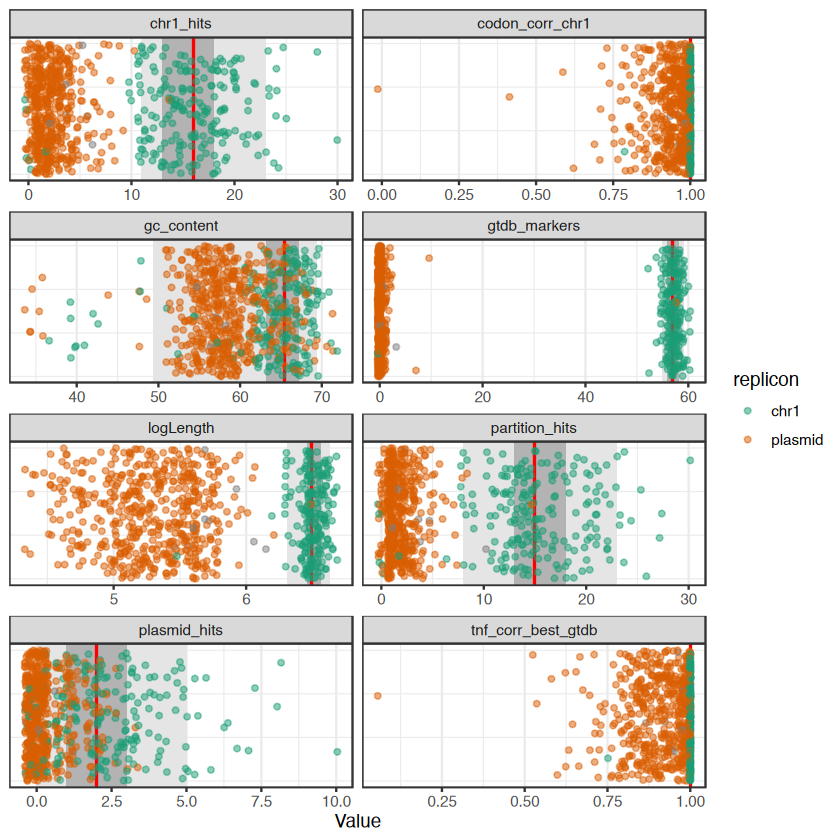

Saving 6.67 x 6.67 in image


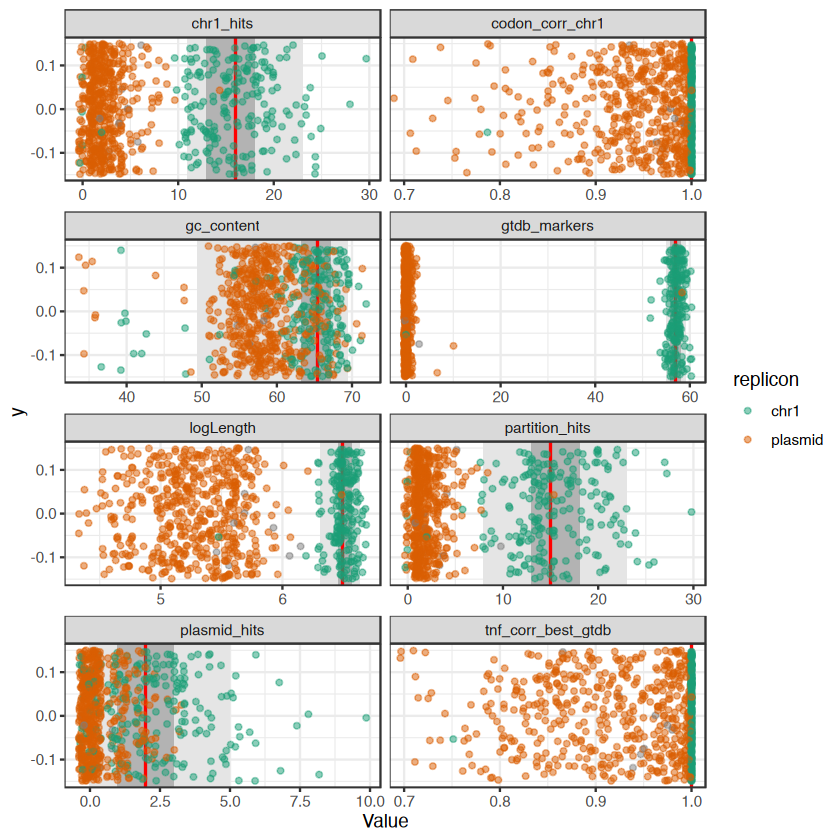

In [5]:
#Inspecting the distribution of each replicon along the values of each genomic feature
#Selecting features
features <- c("logLength",
              "gc_content",
              "tnf_corr_best_gtdb",
              "gtdb_markers",
              "codon_corr_chr1",
              "chr1_hits",
              "partition_hits",
              "plasmid_hits")

#Formatting tables
chr_ref <- feat %>%
  filter(replicon=="chr1") %>%
  summarise(across(all_of(features),
                   list(Q05=~quantile(.,0.05),
                        Q25=~quantile(.,0.25),
                        Med=median,
                        Q75=~quantile(.,0.75),
                        Q95=~quantile(.,0.95)))) %>%
  pivot_longer(everything(),
               names_to=c("Feature",".value"),
               names_sep="_(?=[^_]+$)")

feat_long <- feat %>%
  select(replicon, all_of(features)) %>%
  pivot_longer(-replicon,
               names_to="Feature",
               values_to="Value")

#Plotting all features
ggplot() + geom_rect(data=chr_ref,
            aes(xmin=Q05,
                xmax=Q95,
                ymin=-Inf,
                ymax=Inf),
            fill="grey90") +
  geom_rect(data=chr_ref,
            aes(xmin=Q25,
                xmax=Q75,
                ymin=-Inf,
                ymax=Inf),
            fill="grey70") +
  geom_vline(data=chr_ref,
             aes(xintercept=Med),
             colour="red",
             linewidth=.7) +
  geom_jitter(data=feat_long,
              aes(Value,0,color=replicon),
              height=.15,
              alpha=.5,
              size=1.2) +
  scale_color_manual(
    values = c(
      chr1 = "#1b9e77d9",
      chr2 = "#7570b3ff",
      plasmid = "#d95f02d9"
    )
  ) +
  facet_wrap(~Feature,
             scales="free_x",
             ncol=2) +
  theme_bw() +
  theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        panel.grid.major.y=element_blank())
ggsave("./paper/genomic_features.svg")

#Plotting but removing outliers from TNF and Codon Usage
ggplot() +
  geom_rect(data=chr_ref,
            aes(xmin=Q05, xmax=Q95, ymin=-Inf, ymax=Inf),
            fill="grey90") +
  geom_rect(data=chr_ref,
            aes(xmin=Q25, xmax=Q75, ymin=-Inf, ymax=Inf),
            fill="grey70") +
  geom_vline(data=chr_ref,
             aes(xintercept=Med),
             colour="red",
             linewidth=.7) +
  geom_jitter(data=feat_long,
              aes(Value,0,color=replicon),
              height=.15,
              alpha=.5,
              size=1.2) +
  facet_wrap(~Feature, scales="free_x", ncol=2) +
  scale_color_manual(
    values = c(
      chr1 = "#1b9e77d9",
      chr2 = "#7570b3ff",
      plasmid = "#d95f02d9"
    )
  ) +
  facetted_pos_scales(
    x = list(
      Feature == "codon_corr_chr1" ~ scale_x_continuous(limits = c(0.7, 1)),
      Feature == "tnf_corr_best_gtdb" ~ scale_x_continuous(limits = c(0.7, 1))
    )
  ) +
  theme_bw()
ggsave("./paper/genomic_features_wo_outliers.svg")

Warning message:
“There were 7 warnings in `summarise()`.
The first warning was:
ℹ In argument: `p = cor.test(logLength, Value, method = "spearman")$p.value`.
ℹ In group 1: `Feature = "chr1_hits"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 6 remaining warnings.”
`geom_smooth()` using formula = 'y ~ x'
Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'


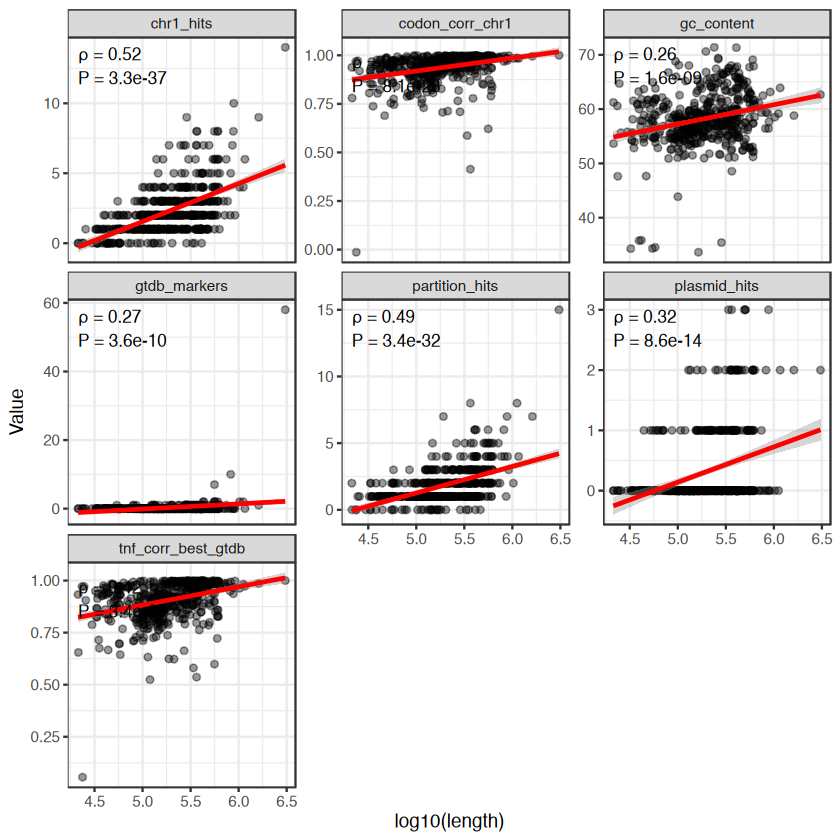

In [6]:
#Correlation between length and the different genomic features evaluated
#Selecting columns from the main table
dat <- plas %>%
  select(logLength,
         chr1_hits,
         codon_corr_chr1,
         gc_content,
         tnf_corr_best_gtdb,
         partition_hits,
         plasmid_hits,
         gtdb_markers) %>%
  pivot_longer(-logLength,
               names_to = "Feature",
               values_to = "Value")

#Spearman correlation for each variable
stats <- dat %>%
  group_by(Feature) %>%
  summarise(rho = cor(logLength, Value,
              method = "spearman",
              use = "pairwise.complete.obs"),
    p = cor.test(logLength, Value,
                 method = "spearman")$p.value,
    x = min(logLength),
    y = max(Value, na.rm = TRUE)) %>%
  mutate(label = paste0("ρ = ",
                        round(rho, 2),
                        "\nP = ",
                        signif(p, 2)))

#Plotting all panels
ggplot(dat,aes(logLength, Value)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", colour = "red", se = TRUE) +
  geom_text(data = stats,
            aes(x = x, y = y, label = label),
            inherit.aes = FALSE,
            hjust = 0,
            vjust = 1,
            size = 3.5) +
  facet_wrap(~Feature, scales = "free_y") +
  theme_bw() +
  labs(x = "log10(length)", y = "Value")
ggsave("./paper/feat_corr.svg")

Saving 6.67 x 6.67 in image
Ignoring unknown labels:
• shape : "Replicon"


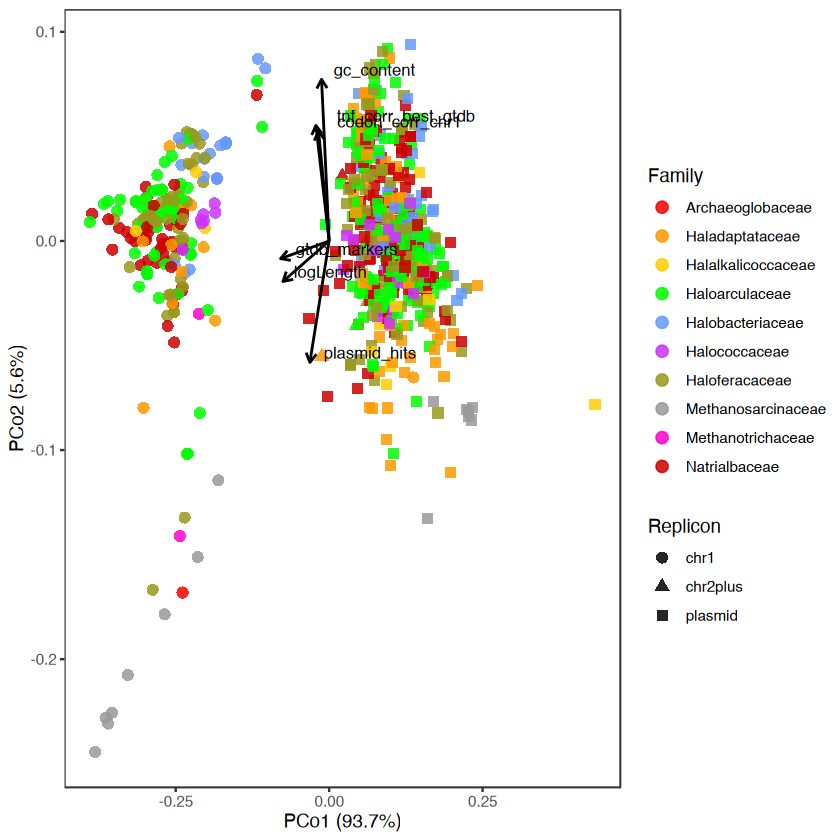

Saving 6.67 x 6.67 in image
Ignoring unknown labels:
• shape : "Replicon"


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,2,19.655980,0.8531432,2117.51,1e-04
Residual,729,3.383504,0.1468568,NA,NA
Total,731,23.039484,1.0000000,NA,NA


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,2,0.01704602,0.008523009,6.584053,0.001465888
Residuals,729,0.94368526,0.001294493,NA,NA



Permutation test for homogeneity of multivariate dispersions
Permutation: free
Number of permutations: 999

Response: Distances
           Df  Sum Sq   Mean Sq      F N.Perm Pr(>F)   
Groups      2 0.01705 0.0085230 6.5841    999   0.01 **
Residuals 729 0.94369 0.0012945                        
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

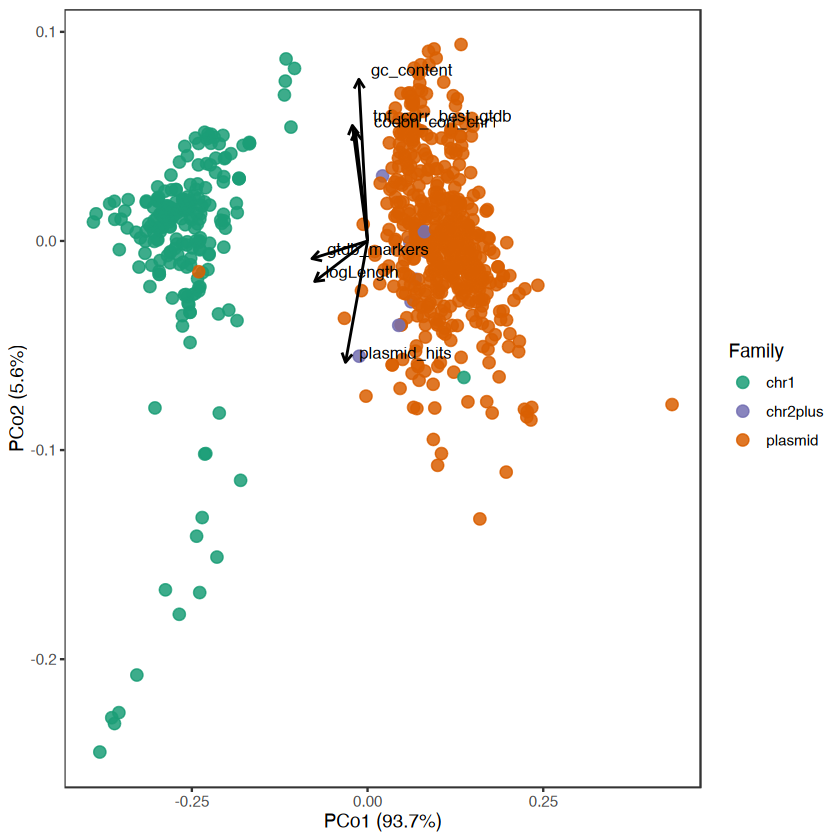

In [7]:
#PCoA ordination using Gower distance on genomic features
#Select genomic features
X <- feat %>%
  select(logLength,
    gc_content,
    tnf_corr_best_gtdb,
    codon_corr_chr1,
    gtdb_markers,
    chr1_hits,
    partition_hits,
    plasmid_hits)

#Calculate Gower distance
gower <- daisy(X, metric = "gower")

#Principal Coordinates Analysis
pcoa <- pcoa(as.matrix(gower))

#Extract first two axes
scores <- as.data.frame(pcoa$vectors[, 1:2])
colnames(scores) <- c("PCo1", "PCo2")

#Add replicon and metadata
scores$replicon <- feat$replicon
scores$genome <- feat$genome
scores$contig <- feat$contig

#Explained variance
var1 <- round(100 * pcoa$values$Relative_eig[1], 1)
var2 <- round(100 * pcoa$values$Relative_eig[2], 1)

#Add taxonomy
scores <- scores %>%
  left_join(
    feat %>%
      select(genome,
        contig,
        phylum,
        class,
        order,
        family,
        genus,
        species),
    by = c("genome", "contig"))

#Fit environmental/genomic feature vectors
fit <- envfit(scores[, c("PCo1", "PCo2")],X,
  permutations = 999)

#Extract vectors
vec <- as.data.frame(scores(fit, display = "vectors"))
vec$Variable <- rownames(vec)

#Keep selected variables
vec <- vec %>%
  filter(Variable %in% c("logLength",
      "gc_content",
      "tnf_corr_best_gtdb",
      "codon_corr_chr1",
      "gtdb_markers",
      "plasmid_hits"))

#Scale arrows to fit the ordination
arrow_scale <- 0.4 * min(diff(range(scores$PCo1)) / diff(range(vec$PCo1)),
  diff(range(scores$PCo2)) / diff(range(vec$PCo2)))

vec$PCo1 <- vec$PCo1 * arrow_scale
vec$PCo2 <- vec$PCo2 * arrow_scale

#Plotting PCoA
ggplot(scores,
  aes(PCo1,PCo2,
    colour = family,
    shape = replicon)) +
  geom_point(size = 2.8,alpha = 0.85) +
  geom_segment(data = vec,
    aes(x = 0,y = 0,
      xend = PCo1,
      yend = PCo2),
    inherit.aes = FALSE,
    colour = "black",
    linewidth = 0.6,
    arrow = arrow(length = unit(0.22, "cm"))) +
  geom_text(data = vec,
    aes(PCo1,PCo2,
      label = Variable),
    inherit.aes = FALSE,
    size = 3.4,
    fontface = "bold",
    hjust = -0.15,
    vjust = -0.3) +
  paletteer::scale_colour_paletteer_d("ggsci::default_ucscgb") +
  theme_bw() +
  labs(x = paste0("PCo1 (", var1, "%)"),
    y = paste0("PCo2 (", var2, "%)"),
    colour = "Family",
    shape = "Replicon") +
  theme(panel.grid = element_blank(),
    legend.position = "right",
    legend.title = element_text(face = "bold"))
ggsave("./paper/pcoa_color_families.svg")

ggplot(scores,
  aes(PCo1,PCo2,
    colour = replicon)) +
  geom_point(size = 2.8,alpha = 0.85) +
  geom_segment(data = vec,
    aes(x = 0,y = 0,
      xend = PCo1,
      yend = PCo2),
    inherit.aes = FALSE,
    colour = "black",
    linewidth = 0.6,
    arrow = arrow(length = unit(0.22, "cm"))) +
  geom_text(data = vec,
    aes(PCo1,PCo2,
      label = Variable),
    inherit.aes = FALSE,
    size = 3.4,
    fontface = "bold",
    hjust = -0.15,
    vjust = -0.3) +
  scale_color_manual(
    values = c(
      chr1 = "#1b9e77d9",
      chr2plus = "#7570b3ff",
      plasmid = "#d95f02d9"
    )
  ) +
  theme_bw() +
  labs(x = paste0("PCo1 (", var1, "%)"),
    y = paste0("PCo2 (", var2, "%)"),
    colour = "Family",
    shape = "Replicon") +
  theme(panel.grid = element_blank(),
    legend.position = "right",
    legend.title = element_text(face = "bold"))

ggsave("./paper/pcoa_features.svg")

#Statistical analysis
#PERMANOVA
adonis2(as.dist(gower) ~ replicon,
  data = feat,
  permutations = 9999)

# Homogeneity of dispersion
disp <- betadisper(
  as.dist(gower),
  feat$replicon)

anova(disp)
permutest(disp)

In [8]:
#Getting the identity of the points in the lower clusters
chr <- feat %>%
    filter(replicon == "chr1") %>%
    mutate(PCo1 = scores$PCo1[feat$replicon=="chr1"],
        PCo2 = scores$PCo2[feat$replicon=="chr1"])

lower <- chr %>%
    filter(PCo2 < -0.07)

upper <- chr %>%
    filter(PCo2 >= -0.07)

#Comparing the upper and lower clusters and different taxonomic levels
compare <- bind_rows(mutate(lower, group="Lower"),
    mutate(upper, group="Upper"))

compare %>%
group_by(group) %>%
summarise(across(c(length,
                   gc_content,
                   gtdb_markers,
                   chr1_hits,
                   tnf_corr_best_gtdb,
                   codon_corr_chr1,
                   partition_hits,
                   plasmid_hits),
                 median,
                 na.rm=TRUE))

compare %>%
    dplyr::count(group, phylum) %>%
    tidyr::pivot_wider(
        names_from = group,
        values_from = n,
        values_fill = 0)

#Getting counts for each cluster
#Counts
counts <- compare %>%
    count(family, group) %>%
    pivot_wider(names_from = group,
        values_from = n,
        values_fill = 0)

#Genome lists
genomes <- compare %>%
    group_by(family, group) %>%
    summarise(Genomes = paste(sort(unique(genome)), collapse = "; "),
        .groups = "drop") %>%
    pivot_wider(names_from = group,
        values_from = Genomes,
        names_prefix = "Genomes_",
        values_fill = "")

#Merge both tables
low_upper <- counts %>%
    left_join(genomes, by = "family") %>%
    arrange(family)
head(low_upper)

ts5 <- compare %>%
  group_by(family, group) %>%
  summarise(across(c(length,
        gc_content,
        gtdb_markers,
        chr1_hits,
        tnf_corr_best_gtdb,
        codon_corr_chr1,
        partition_hits,
        plasmid_hits),
      median,na.rm = TRUE),.groups = "drop")
head(ts5)
write.table(ts5, "./paper/family_feature_count.tsv", sep="\t", quote=FALSE, row.names=FALSE)

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(...)`.
ℹ In group 1: `group = "Lower"`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


group,length,gc_content,gtdb_markers,chr1_hits,tnf_corr_best_gtdb,codon_corr_chr1,partition_hits,plasmid_hits
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Lower,3484750,42.315,56,16,1,1,16,3
Upper,3115374,65.660,57,16,1,1,14,2


phylum,Lower,Upper
<chr>,<int>,<int>
Halobacteriota,16,195


family,Lower,Upper,Genomes_Lower,Genomes_Upper
<chr>,<int>,<int>,<chr>,<chr>
Archaeoglobaceae,1,0,GCF_000025285.1,
Haladaptataceae,1,13,GCF_020700235.1,GCF_004087835.1; GCF_008831545.1; GCF_020614375.1; GCF_020618475.1; GCF_023238205.1; GCF_024138125.1; GCF_024138165.1; GCF_024218795.1; GCF_024227995.1; GCF_026248685.1; GCF_029338375.1; GCF_029338395.1; GCF_049568665.1
Halalkalicoccaceae,0,3,,GCF_000196895.1; GCF_036429475.1; GCF_036584055.1
Haloarculaceae,3,51,GCF_025947005.1; GCF_026013925.1; GCF_027563145.1,GCF_000011085.1; GCF_000023965.1; GCF_000026045.1; GCF_000223905.1; GCF_000470655.1; GCF_000504565.1; GCF_000827835.1; GCF_001989615.1; GCF_004803735.1; GCF_005310945.1; GCF_009617995.1; GCF_011602445.1; GCF_017094445.1; GCF_017094465.1; GCF_018200015.1; GCF_020217425.1; GCF_020405185.1; GCF_020405245.1; GCF_023028225.1; GCF_023028345.1; GCF_023115355.1; GCF_024218775.1; GCF_024218815.1; GCF_024227715.1; GCF_024228315.1; GCF_024298865.1; GCF_024298885.1; GCF_024298905.1; GCF_024300825.1; GCF_024362405.1; GCF_025231485.1; GCF_026410925.1; GCF_028747785.1; GCF_029278565.1; GCF_029338195.1; GCF_029338235.1; GCF_029338255.1; GCF_029338275.1; GCF_029338315.1; GCF_029338355.1; GCF_029338575.1; GCF_030127105.1; GCF_030505615.1; GCF_035666295.1; GCF_037335815.1; GCF_037338445.1; GCF_041530035.1; GCF_047715405.1; GCF_048595605.1; GCF_049603855.1; GCF_051122755.1
Halobacteriaceae,0,20,,GCF_000006805.1; GCF_000069025.1; GCF_001011115.1; GCF_001305655.1; GCF_001488575.1; GCF_003721175.2; GCF_004799605.1; GCF_007833275.1; GCF_016917835.2; GCF_016917855.1; GCF_020614395.1; GCF_020736485.1; GCF_021233415.1; GCF_021233435.1; GCF_021249405.1; GCF_024972755.1; GCF_030345255.1; GCF_037094595.1; GCF_037482175.1; GCF_040435975.1
Halococcaceae,0,7,,GCF_022870485.1; GCF_029338215.1; GCF_029338295.1; GCF_029489995.1; GCF_052043865.1; GCF_052043925.1; GCF_052598275.1


family,group,length,gc_content,gtdb_markers,chr1_hits,tnf_corr_best_gtdb,codon_corr_chr1,partition_hits,plasmid_hits
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Archaeoglobaceae,Lower,1560622,42.01,55,19,1,1,11,3
Haladaptataceae,Lower,3821467,58.76,58,15,1,1,17,7
Haladaptataceae,Upper,3037152,65.13,58,15,1,1,14,2
Halalkalicoccaceae,Upper,3436347,65.24,56,14,1,1,13,2
Haloarculaceae,Lower,3881378,54.43,57,16,1,1,15,1
Haloarculaceae,Upper,3304793,65.80,57,16,1,1,19,2


In [9]:
#PCoA ordination using Bray-Curtis distance on replicon functional annotations

Saving 6.67 x 6.67 in image


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,2,9.076315,0.1467917,64.86162,1e-04
Residual,754,52.754940,0.8532083,NA,NA
Total,756,61.831256,1.0000000,NA,NA


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,2,8.376051,4.188025367,428.3363,5.336435e-125
Residuals,754,7.372177,0.009777423,NA,NA



Permutation test for homogeneity of multivariate dispersions
Permutation: free
Number of permutations: 999

Response: Distances
           Df Sum Sq Mean Sq      F N.Perm Pr(>F)    
Groups      2 8.3761  4.1880 428.34    999  0.001 ***
Residuals 754 7.3722  0.0098                         
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


***VECTORS

               Dim1      Dim2     r2 Pr(>r)    
logLength -0.997350  0.072773 0.5615  0.001 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
Permutation: free
Number of permutations: 999



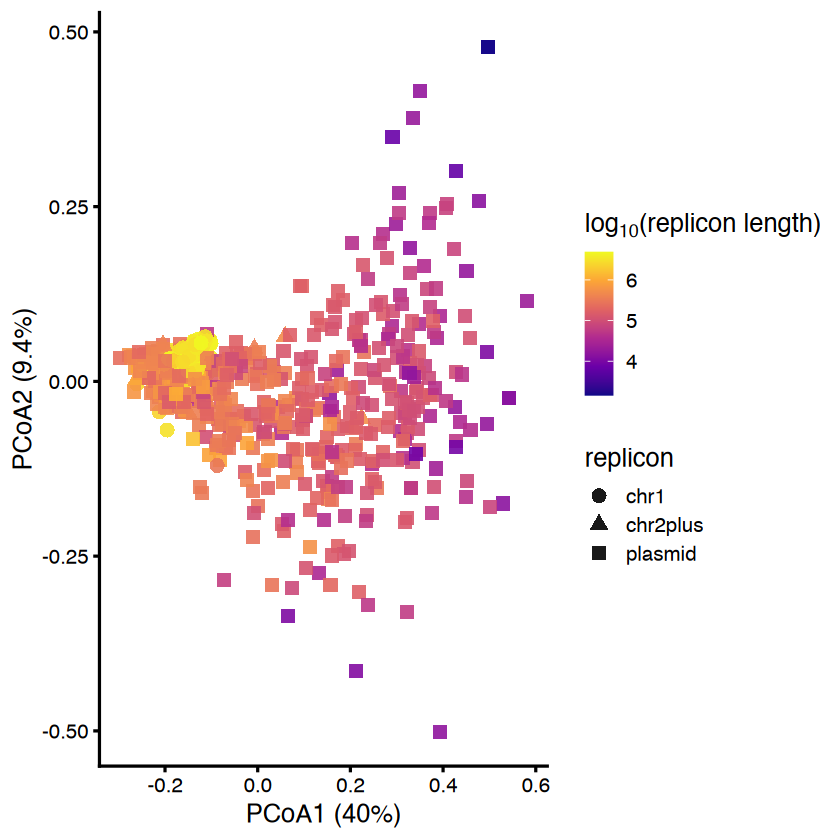

In [10]:
#Loading tables
master <- read.delim("arch_cluster_master.tsv",
    header = FALSE,
    stringsAsFactors = FALSE,
    col.names = c("cluster",
        "gene",
        "genome",
        "contig",
        "replicon"))

annot <- read.delim("arch_cluster_annotation.tsv",stringsAsFactors = FALSE)
meta <- read.delim("replicon_all_metadata_tax_2.tsv",stringsAsFactors = FALSE)

#Join annotations
dat <- master %>%
    left_join(annot,by="cluster")

#Expand multiple COG categories
dat <- dat %>%
    mutate(COG_category = gsub(" ","",COG_category)) %>%
    separate_rows(COG_category,sep="") %>%
    filter(COG_category != "")

#Fltering the table to remove all entries that are not Halobacteriota
dat <- dat %>%
  filter(genome %in% meta$genome[meta$phylum == "Halobacteriota"])

#Constructing a relative abundance matrix
mat <- dat %>%
    count(contig,COG_category) %>%
    group_by(contig) %>%
    mutate(abundance = n/sum(n)) %>%
    ungroup() %>%
    select(contig,
        COG_category,
        abundance) %>%
    pivot_wider(names_from = COG_category,
        values_from = abundance,
        values_fill = 0)

#Matrix
X <- as.data.frame(mat)
rownames(X) <- X$contig
X$contig <- NULL
X <- as.matrix(X)

#Obtaining Bray-Curtis distance
dist_mat <- vegdist(X,
    method="bray")

#PCoA construction
pcoa <- cmdscale(dist_mat,
    eig=TRUE, k=2)

scores <- data.frame(contig = rownames(X),
    PC1 = pcoa$points[,1],
    PC2 = pcoa$points[,2])

#Metadata
scores <- scores %>%
    left_join(meta %>%
            select(contig,
                family,
                replicon,
                length),
        by="contig") %>%
    mutate(logLength = log10(length))

#Variance explained
var <- round(100*pcoa$eig[1:2]/sum(pcoa$eig[pcoa$eig>0]),1)

#Plotting the ordination
ggplot(scores,
    aes(PC1,
        PC2,
        colour=logLength,
        shape=replicon))+
geom_point(size=3.5,
    alpha=.9)+
scale_colour_viridis_c(
    option="plasma",
    name=expression(log[10]*"(replicon length)"))+
theme_classic(base_size=15)+
labs(x=paste0("PCoA1 (",var[1],"%)"),
    y=paste0("PCoA2 (",var[2],"%)"))

ggsave("./paper/pcoa_cog_length.svg")

#Statistical analysis
#PERMANOVA
adonis2(dist_mat ~ replicon,
    data = scores,
    permutations = 9999)

#Homogeneity of dispersion
disp <- betadisper(dist_mat,scores$replicon)
anova(disp)
permutest(disp)

#Variables associated with the ordination
Xenv <- scores %>%
    select(logLength)

fit <- envfit(pcoa$points,
    Xenv,
    permutations = 999)
fit

In [30]:
#Testing the continuumm along all plasmids using length

Saving 6.67 x 6.67 in image


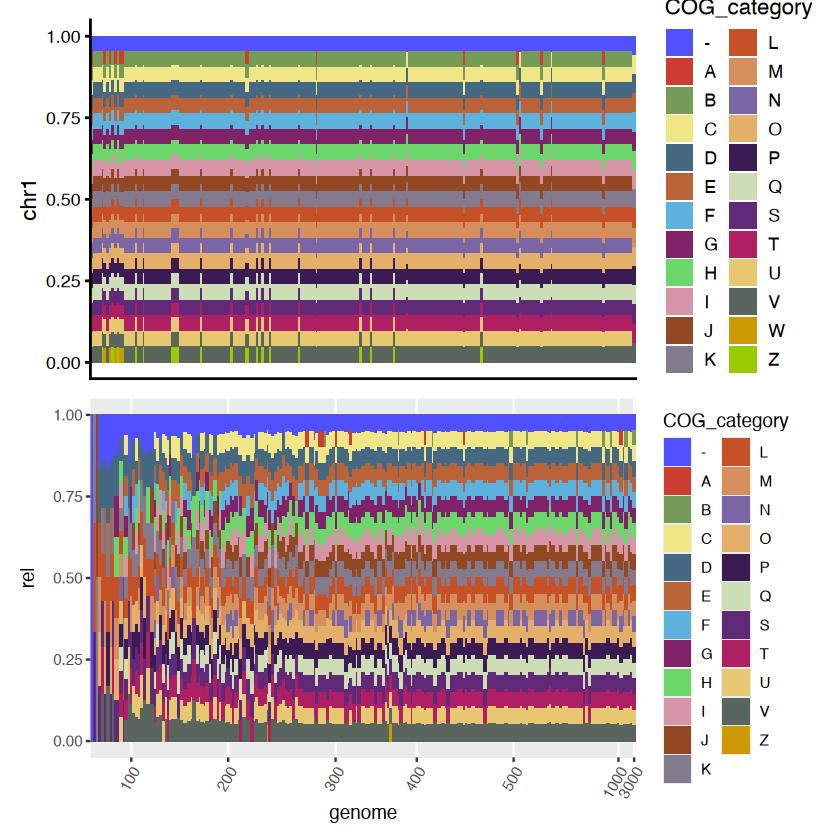

In [11]:
#Collapse accessory replicons (chr2 + plasmids) into "accessory" category
plot_df <- dat %>%
  mutate(group = ifelse(replicon == "chr1", "chr1", "accessory")) %>%
  left_join(meta %>%
      select(genome, contig, length),
    by = c("genome", "contig")) %>%
  count(genome, group, COG_category, wt = 1) %>%
  group_by(genome, group) %>%
  mutate(rel = n / sum(n)) %>%
  ungroup()

#Genome order according to length of secondary replicon
genome_order <- meta %>%
  filter(replicon != "chr1") %>%
  group_by(genome) %>%
  summarise(Length = max(length), .groups = "drop") %>%
  arrange(Length)

# Original evenly spaced ticks
tick_idx1 <- pretty(seq_len(nrow(genome_order)), n = 6)
tick_idx1 <- unique(round(tick_idx1))
tick_idx1 <- tick_idx1[tick_idx1 >= 1 & tick_idx1 <= nrow(genome_order)]

desired_kb <- c(100, 200, 300, 400, 500, 1000, 3000)

tick_idx <- sapply(desired_kb * 1000, function(x)
  which.min(abs(genome_order$Length - x)))

tick_genomes <- genome_order$genome[tick_idx]
tick_labels <- desired_kb

#Plotting chr1
chr1 <- plot_df %>%
  filter(group == "chr1") %>%
  left_join(genome_order, by = "genome") %>%
  mutate(genome = factor(genome, levels = genome_order$genome))

#Plotting accessory replicons
acc <- plot_df %>%
  filter(group == "accessory") %>%
  left_join(genome_order, by = "genome") %>%
  mutate(genome = factor(genome, levels = genome_order$genome))

#Adding colors
cols <- paletteer_d("ggsci::default_igv")

#Edditing chr1 panel
p_chr1 <- ggplot(chr1,aes(genome, rel, fill = COG_category)) +
  geom_col(width = 1) +
  scale_fill_manual(values = cols) +
  scale_x_discrete(
    breaks = tick_genomes,
    labels = tick_labels) +
  theme_classic(base_size = 13) +
  theme(axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    legend.position = "none") +
  labs(x = NULL, y = "chr1")

#Edditing accessory panel
p_acc <- ggplot(acc,aes(genome, rel, fill = COG_category)) +
  geom_col(width = 1) +
  scale_fill_manual(values = cols) +
scale_x_discrete(breaks = tick_genomes,labels = tick_labels) +
theme(axis.text.x = element_text(angle = 60,
                               hjust = 1,
                               vjust = 1))

#Constructing final figure
p_chr1 / p_acc +
  plot_layout(heights = c(1, 1),guides = "collect") &
  theme(legend.position = "right")

ggsave("./paper/barplot_cog_length.svg")

Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$length,

,COG,rho,p,FDR
,<chr>,<dbl>,<dbl>,<dbl>
rho...1,E,0.7313308,1.802124e-92,4.144886e-91
rho...2,G,0.7022108,2.663860e-82,3.063439e-81
rho...3,C,0.6937887,1.378324e-79,1.056715e-78
rho...4,H,0.6580552,4.804070e-69,2.762340e-68
rho...5,Q,0.6411979,1.479655e-64,6.806415e-64
rho...6,-,-0.5980760,2.893466e-54,1.109162e-53


Saving 6.67 x 6.67 in image


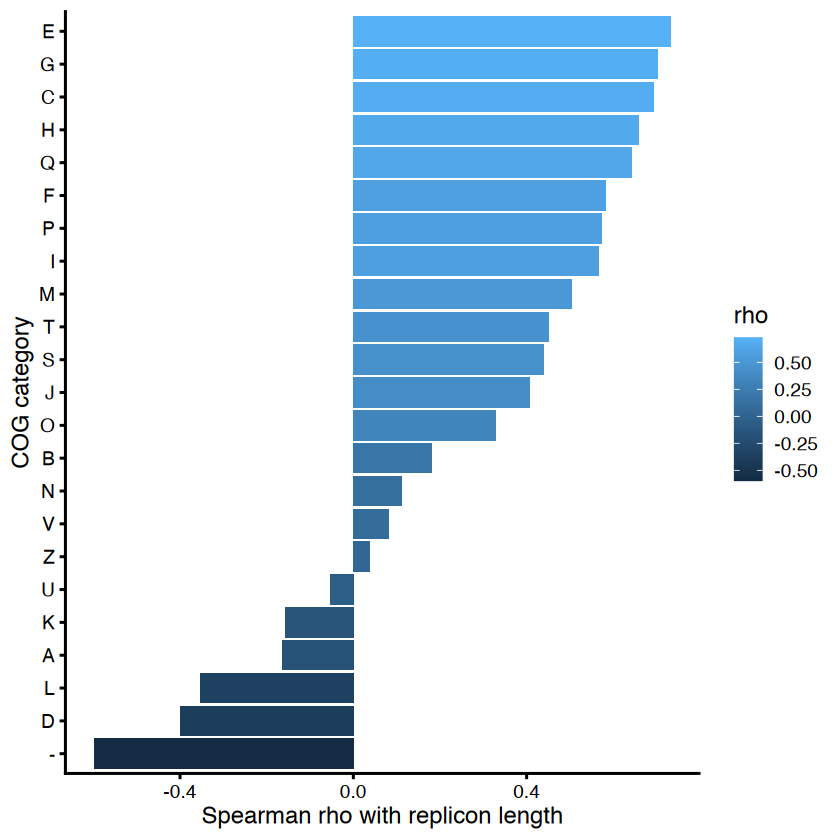

In [12]:
#Defining enriched categories in secondary replicons according to length
#Relative abundance of COGs
cog_rel <- dat %>%
    filter(replicon != "chr1") %>%
    left_join(meta %>%
            select(contig, length),
        by="contig") %>%
    count(contig,
        COG_category,
        length) %>%
    group_by(contig) %>%
    mutate(rel = n/sum(n)) %>%
    ungroup()

#Wide table
cog_wide <- cog_rel %>%
    select(contig,
        length,
        COG_category,
        rel) %>%
    pivot_wider(names_from = COG_category,
        values_from = rel,
        values_fill = 0)

#Calculating Spearman correlation with replicon length
cogs <- setdiff(colnames(cog_wide),
    c("contig","length"))

results <- map_dfr(
    cogs,
    function(cog){
        tmp <- cor.test(
            cog_wide[[cog]],
            cog_wide$length,
            method="spearman")
        data.frame(COG=cog,
            rho=tmp$estimate,
            p=tmp$p.value)})

#Correcting p-values for multiple testing 
results$FDR <- p.adjust(results$p,method="BH")
results <- results %>%
    arrange(desc(abs(rho)))

#Significant COGs
sig <- results %>%
    filter(FDR < 0.05)
head(sig)

#Plotting
ggplot(results,aes(reorder(COG,rho),
        rho,
        fill=rho))+
geom_col()+coord_flip()+
theme_classic(base_size=14)+
labs(x="COG category",
    y="Spearman rho with replicon length")
ggsave("./paper/corr_cog_length.svg")

Warning message in cor.test.default(plot_dat$length, plot_dat$FractionShared, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  plot_dat$length and plot_dat$FractionShared
S = 24179015, p-value = 1.455e-12
alternative hypothesis: true rho is not equal to 0
sample estimates:
     rho 
0.286393 


,genome,contig,TotalClusters,SharedClusters,length,replicon,FractionShared
,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<dbl>
1,GCF_000006805.1,NC_001869.1,133,12,191346,plasmid,0.09022556
2,GCF_000006805.1,NC_002608.1,278,22,365425,plasmid,0.07913669
3,GCF_000009185.1,NC_008213.1,47,4,46867,plasmid,0.08510638
4,GCF_000011085.1,NC_006389.1,46,2,33303,plasmid,0.04347826
5,GCF_000011085.1,NC_006390.1,44,5,33452,plasmid,0.11363636
6,GCF_000011085.1,NC_006391.1,49,3,39521,plasmid,0.06122449


`geom_smooth()` using formula = 'y ~ x'
Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'


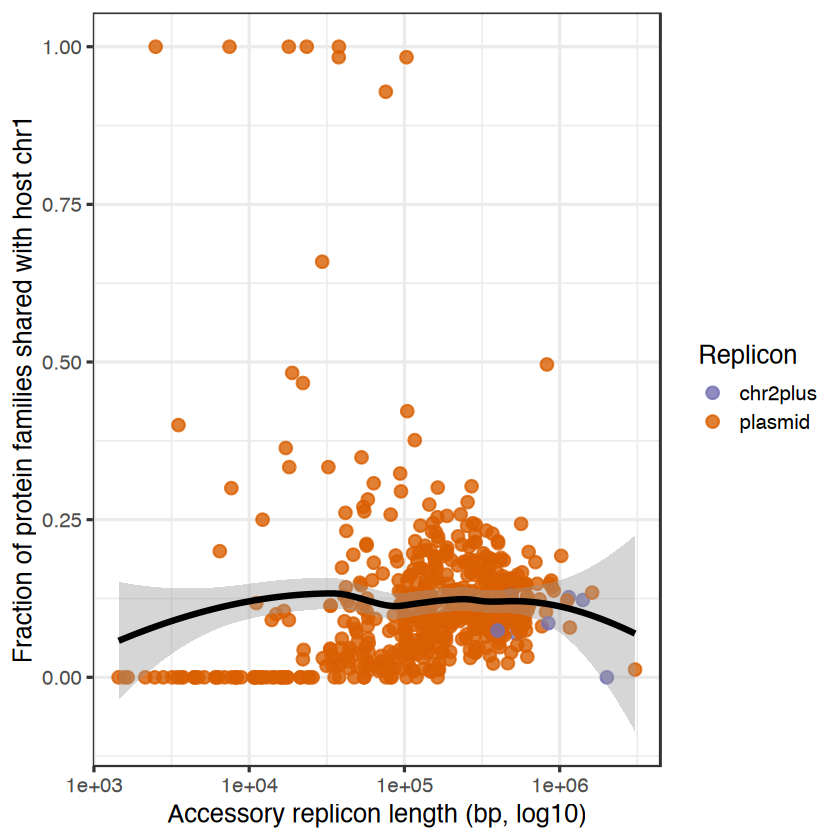

In [13]:
#Checking if accessory replicon size is related with the number of proteins shared with chr1
#Naming columns in master table
colnames(master) <- c("cluster","protein","genome","contig","replicon")

#Keep chr1, plasmids and chr2plus
dat <- master %>%
    filter(replicon %in% c("chr1","plasmid","chr2plus"))

#Number of protein families per accessory replicon
accessory_total <- dat %>%
    filter(replicon %in% c("plasmid","chr2plus")) %>%
    distinct(genome,
        contig,
        cluster) %>%
    count(genome,
        contig,
        name="TotalClusters")

# Shared protein families with host chr1
chr1_clusters <- dat %>%
    filter(replicon=="chr1") %>%
    distinct(genome,
        cluster)

shared <- dat %>%
    filter(replicon %in% c("chr1","plasmid","chr2plus")) %>%
    distinct(genome,
        contig,
        cluster) %>%
    inner_join(chr1_clusters,
        by=c("genome","cluster")) %>%
    count(genome,
        contig,
        name="SharedClusters")

# Accessory replicon length
replicon_features_full <- read.delim("replicon_all_metadata_tax.tsv",
    header=TRUE,
    stringsAsFactors=FALSE)

colnames(replicon_features_full) <- c("genome","contig","replicon","length","gc_content",
    "gtdb_markers","tnf_corr_best_gtdb",
    "chr1_presence","chr1_hits",
    "partition_presence","partition_hits",
    "plasmid_presence","plasmid_hits",
    "phylum","class","order","family","genus","species",
    "chr1_gc","delta_gc","abs_delta_gc")

accessory_length <- replicon_features_full %>%
    filter(replicon %in% c("plasmid","chr2plus")) %>%
    select(genome,
        contig,
        length,
        replicon)

# Merge
plot_dat <- accessory_total %>%
    left_join(shared,
        by=c("genome","contig")) %>%
    left_join(accessory_length,
        by=c("genome","contig")) %>%
    mutate(SharedClusters=ifelse(
            is.na(SharedClusters),
            0,SharedClusters),
        FractionShared=SharedClusters/TotalClusters)

# Correlation
cor.test(plot_dat$length,
    plot_dat$FractionShared,
    method="spearman")

head(plot_dat)

# Plotting
ggplot(plot_dat,
    aes(x=length,
        y=FractionShared,
        colour=replicon)) +
    geom_point(size=2.8,
        alpha=.8) +
    geom_smooth(aes(group=1),
        method="loess",
        colour="black",
        se=TRUE) +
    scale_x_log10() +
    scale_color_manual(values=c(chr2plus="#7570b3ff",
            plasmid="#d95f02d9")) +
    theme_bw(base_size=15) +
    labs(x="Accessory replicon length (bp, log10)",
        y="Fraction of protein families shared with host chr1",
        colour="Replicon")
ggsave("./paper/shared_chr1_second.svg")

In [38]:
#Testing the continuumm along all plasmids using TNF

Saving 6.67 x 6.67 in image


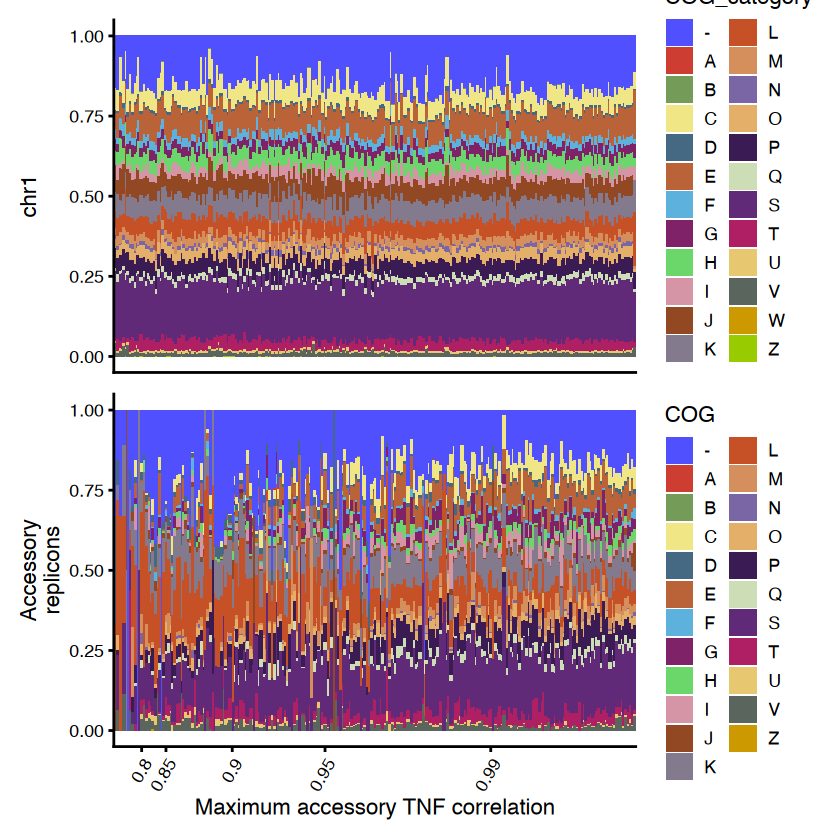

In [14]:
#Recreating dat object
#Join annotations
dat <- master %>%
    left_join(annot,by="cluster")

#Expand multiple COG categories
dat <- dat %>%
    mutate(COG_category = gsub(" ","",COG_category)) %>%
    separate_rows(COG_category,sep="") %>%
    filter(COG_category != "")
#Collapse accessory replicons
plot_df <- dat %>%
  mutate(group = ifelse(replicon == "chr1", "chr1", "accessory")) %>%
  count(genome, group, COG_category) %>%
  group_by(genome, group) %>%
  mutate(rel = n / sum(n)) %>%
  ungroup()

#Genome order (using accessory TNF)
genome_order <- meta %>%
  filter(replicon != "chr1") %>%
  group_by(genome) %>%
  summarise(TNF = max(tnf_corr_best_gtdb), .groups = "drop") %>%
  arrange(TNF)

#Desired TNF values for x-axis labels
desired_tnf <- c(0.80, 0.85, 0.90, 0.95, 0.99)

tick_idx <- sapply(desired_tnf, function(x)
  which.min(abs(genome_order$TNF - x)))

tick_idx <- unique(tick_idx)

tick_genomes <- genome_order$genome[tick_idx]
tick_labels <- desired_tnf

#chr1 data
chr1 <- plot_df %>%
  filter(group == "chr1") %>%
  left_join(genome_order, by = "genome") %>%
  mutate(genome = factor(genome, levels = genome_order$genome))

#accessory data
acc <- plot_df %>%
  filter(group == "accessory") %>%
  left_join(genome_order, by = "genome") %>%
  mutate(genome = factor(genome, levels = genome_order$genome))

#Adding colors
cols <- paletteer_d("ggsci::default_igv")

#Constructing chromosome panel
p_chr1 <- ggplot(chr1,aes(genome, rel, fill = COG_category)) +
  geom_col(width = 1) +
  scale_fill_manual(values = cols) +
  theme_classic(base_size = 13) +
  theme(axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    legend.position = "none") +
  labs(x = NULL, y = "chr1")

#Constructing accessory panel
p_acc <- ggplot(acc,aes(genome, rel, fill = COG_category)) +
  geom_col(width = 1) +
  scale_fill_manual(values = cols) +
  scale_x_discrete(breaks = tick_genomes,
    labels = tick_labels) +
  theme_classic(base_size = 13) +
  theme(axis.text.x = element_text(angle = 60,
      hjust = 1, vjust = 1)) +
  labs(x = "Maximum accessory TNF correlation",
    y = "Accessory\nreplicons",
    fill = "COG")

#Creating final figure
p_chr1 / p_acc +
  plot_layout(
    heights = c(1, 1),
    guides = "collect") & theme(legend.position = "right")
ggsave("./paper/barplot_cog_tnf.svg")

Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(cog_wide[[cog]], cog_wide$tnf_corr_best_gtdb, :
“Cannot compute exact p-value with ties”


,COG,rho,p,FDR
,<chr>,<dbl>,<dbl>,<dbl>
rho...1,E,0.5138883,3.331034e-40,7.661378e-39
rho...2,L,-0.5086639,2.691930e-39,3.095719e-38
rho...3,G,0.5045933,1.337631e-38,1.025517e-37
rho...4,C,0.5016290,4.241328e-38,2.438764e-37
rho...5,-,-0.4566710,4.534300e-31,2.085778e-30
rho...6,S,0.4326294,1.018099e-27,3.902714e-27


Saving 6.67 x 6.67 in image


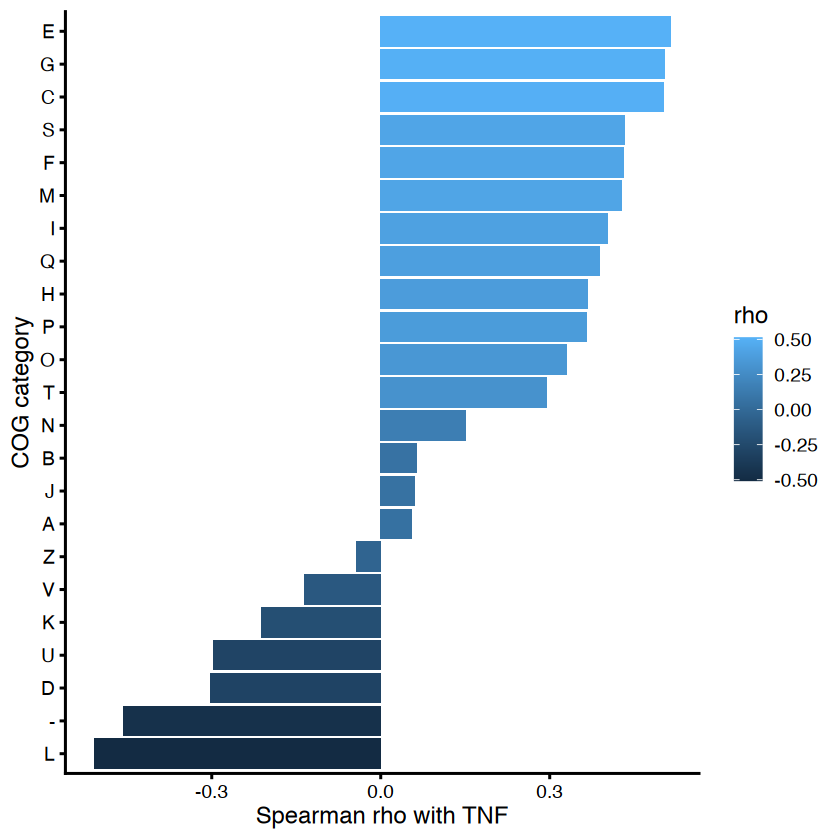

In [15]:
#Relative abundance of COGs per replicon
cog_rel <- dat %>%
        left_join(meta %>%
        select(contig, tnf_corr_best_gtdb), by="contig") %>%
    filter(replicon != "chr1") %>%
    count(contig,
        COG_category,
        tnf_corr_best_gtdb) %>%
    group_by(contig) %>%
    mutate(rel = n / sum(n)) %>%
    ungroup()

#Wide matrix
cog_wide <- cog_rel %>%
    select(contig,
        tnf_corr_best_gtdb,
        COG_category,
        rel) %>%
    pivot_wider(
        names_from = COG_category,
        values_from = rel,
        values_fill = 0)

#Calculating Spearman correlation with replicon TNF
cogs <- setdiff(colnames(cog_wide),
    c("contig","tnf_corr_best_gtdb"))

results <- map_dfr(cogs,
    function(cog){
        tmp <- cor.test(
            cog_wide[[cog]],
            cog_wide$tnf_corr_best_gtdb,
            method = "spearman")
        data.frame(COG = cog,
            rho = tmp$estimate,
            p = tmp$p.value)})

#Multiple testing correction
results$FDR <- p.adjust(results$p,
    method = "BH")
results <- results %>%
    arrange(desc(abs(rho)))

#Significant COGs
sig <- results %>%
    filter(FDR < 0.05)
head(sig)

#Plotting
ggplot(results,
    aes(reorder(COG, rho),
        rho, fill = rho))+
geom_col()+coord_flip()+
theme_classic(base_size = 14)+
labs(x = "COG category",y = "Spearman rho with TNF")
ggsave("./paper/corr_cog_tnf.svg")

In [22]:
#Checking if the larger the replicon the more number of duplicates present

In [16]:
dup <- master %>%
  group_by(genome, contig, replicon, cluster) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(genome, contig, replicon) %>%
  summarise(
    DuplicatedFamilies = sum(n > 1),
    TotalFamilies = n(),
    FractionDuplicated = DuplicatedFamilies / TotalFamilies,
    .groups = "drop")
dup <- dup %>%
    filter(replicon != "unknown")

# Add replicon lengths
replicon_features_full <- read.delim("replicon_all_metadata_tax.tsv",
    header = TRUE, stringsAsFactors = FALSE)%>%
    rename(Genome = genome, Contig = contig)
colnames(replicon_features_full) <- c("genome","contig","replicon","length","gc_content","gtdb_markers","tnf_corr_best_gtdb",
                                      "chr1_presence","chr1_hits","partition_presence","partition_hits","plasmid_presence",
                                      "plasmid_hits","phylum","class","order","family","genus","species","chr1_gc",
                                      "delta_gc","abs_delta_gc")

replicon_features_full <- replicon_features_full %>%
        filter(replicon != "unknown")

dup <- dup %>%
  left_join(replicon_features_full %>%
      select(genome, contig, length),
    by = c("genome", "contig"))

dup <- dup %>%
  mutate(length = as.numeric(length))

head(dup)

genome,contig,replicon,DuplicatedFamilies,TotalFamilies,FractionDuplicated,length
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
GCF_000006805.1,NC_001869.1,plasmid,48,133,0.36090226,191346
GCF_000006805.1,NC_002607.1,chr1,54,2053,0.02630297,2014239
GCF_000006805.1,NC_002608.1,plasmid,61,278,0.21942446,365425
GCF_000009185.1,NC_008212.1,chr1,112,2860,0.03916084,3132494
GCF_000009185.1,NC_008213.1,plasmid,1,47,0.02127660,46867
GCF_000011085.1,NC_006389.1,plasmid,1,46,0.02173913,33303


In [17]:
#Absolute number of duplicated families
cor.test(dup$length,
         dup$DuplicatedFamilies,
         method = "spearman")

#Fraction of duplicated families
cor.test(dup$length,
         dup$FractionDuplicated,
         method = "spearman")

Warning message in cor.test.default(dup$length, dup$DuplicatedFamilies, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  dup$length and dup$DuplicatedFamilies
S = 6857953, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.9280365 


Warning message in cor.test.default(dup$length, dup$FractionDuplicated, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  dup$length and dup$FractionDuplicated
S = 61678868, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3527769 


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `p = cor.test(length, DuplicatedFamilies, method = "spearman")$p.value`.
ℹ In group 1: `replicon = "chr1"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


replicon,rho,p
<chr>,<dbl>,<dbl>
chr1,0.8431109,1.324611e-66
chr2plus,0.8545455,3.504744e-03
plasmid,0.8238598,3.785621e-144


Saving 6.67 x 6.67 in image
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


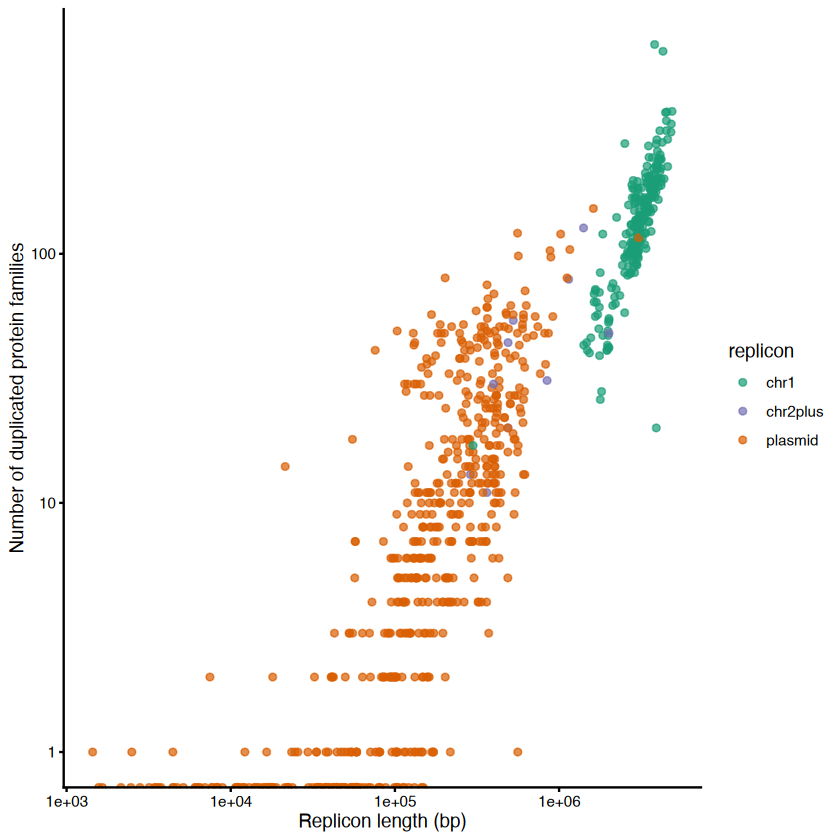

In [18]:
#Plotting
ggplot(dup, aes(length, DuplicatedFamilies, colour = replicon)) +
    geom_point(alpha = 0.7) +
    scale_color_manual(
    values = c(
      chr1 = "#1b9e77d9",
      chr2plus = "#7570b3ff",
      plasmid = "#d95f02d9")) +
    scale_x_log10() +
    scale_y_log10() +
    theme_classic() +
    labs(x = "Replicon length (bp)",
        y = "Number of duplicated protein families")

#Statistical analysis
dup %>%
  group_by(replicon) %>%
  summarise(rho = cor(length,
              DuplicatedFamilies,
              method = "spearman"),
    p = cor.test(length,
                 DuplicatedFamilies,
                 method = "spearman")$p.value)
ggsave("./paper/duplicated_clusters.svg")